In [2]:
import pandas as pd
import os
import numpy as np 
import matplotlib.pyplot as plt
from sklearn import linear_model

In [3]:
current_path = os.getcwd()

In [4]:
current_path

'c:\\Users\\henrique.cordeiro\\OneDrive - Sociedade Campineira de Educação e Instrução\\A-POS\\não_supervisionado'

In [5]:
csv_path = current_path + "/FuelConsumptionCo2.csv"

In [14]:
df = pd.read_csv(csv_path)

In [7]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [9]:
df.columns

Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='object')

In [15]:
dados = df[["ENGINESIZE","CO2EMISSIONS"]]
dados

,ENGINESIZE,CO2EMISSIONS
0,2.0,196
1,2.4,221
2,1.5,136
3,3.5,255
4,3.5,244
...,...,...
1062,3.0,271
1063,3.2,264
1064,3.0,271
1065,3.2,260


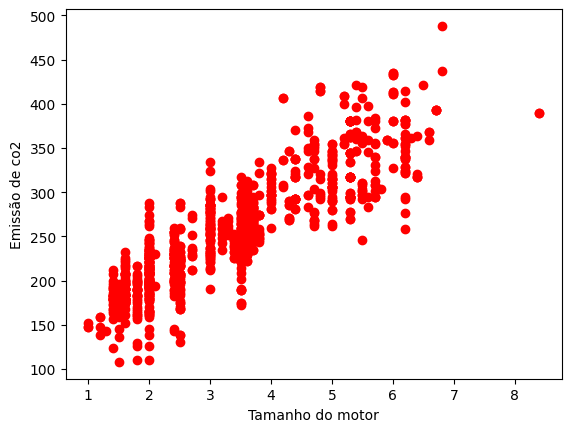

In [16]:
plt.scatter(dados["ENGINESIZE"],dados["CO2EMISSIONS"],color="red")
plt.xlabel("Tamanho do motor")
plt.ylabel("Emissão de co2")
plt.show()

In [ ]:
print("dados",len(dados))
treino = dados[:(int((len(dados)*0.8)))] 
print("treino",len(treino))
teste = dados[(int((len(dados)*0.8))):] 
print("teste",len(teste))


dados 1067
treino 853
teste 214


In [21]:
regressao = linear_model.LinearRegression()
treino_x = np.array(treino[["ENGINESIZE"]])
treino_y = np.array(treino[["CO2EMISSIONS"]])

regressao.fit(treino_x,treino_y)
print("Coeficente de regressão", regressao.coef_)
print("Interceptação", regressao.intercept_)

Coeficente de regressão [[38.79512384]]
Interceptação [127.16989951]


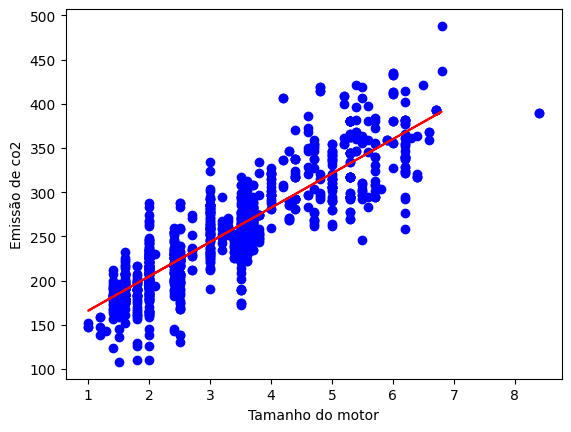

In [22]:
plt.scatter(dados["ENGINESIZE"],dados["CO2EMISSIONS"],color="blue")
plt.plot(treino_x,regressao.coef_*treino_x + regressao.intercept_,"-r")
plt.xlabel("Tamanho do motor")
plt.ylabel("Emissão de co2")
plt.show()

In [23]:
def obter_previsao_regressao(motor, interceptacao,coef_regressao):
    valores_previstos = motor*coef_regressao+interceptacao
    return valores_previstos

In [30]:
tamanho_motor = float(input("Qual o tamanho do motor:"))

emissao_estimada = obter_previsao_regressao(tamanho_motor,regressao.intercept_[0],regressao.coef_[0][0])
print(f"Emissao estimada para o tamanho de motor {tamanho_motor}:",round(emissao_estimada,2))

Emissao estimada para o tamanho de motor 7.5: 418.13


In [31]:
from sklearn.metrics import r2_score 
test_x = np.array(teste[["ENGINESIZE"]])
test_y = np.array(teste[["CO2EMISSIONS"]])
test_y_ = regressao.predict(test_x)

print("Erro médio absoluto", np.mean(np.absolute(test_y - test_y)))
print("Média da soma dos quadrados:",np.mean((test_y_ - test_y)**2))
print("R2-score:",r2_score(test_y_,test_y))



Erro médio absoluto 0.0
Média da soma dos quadrados: 746.4537521463631
R2-score: 0.7097615711759007
